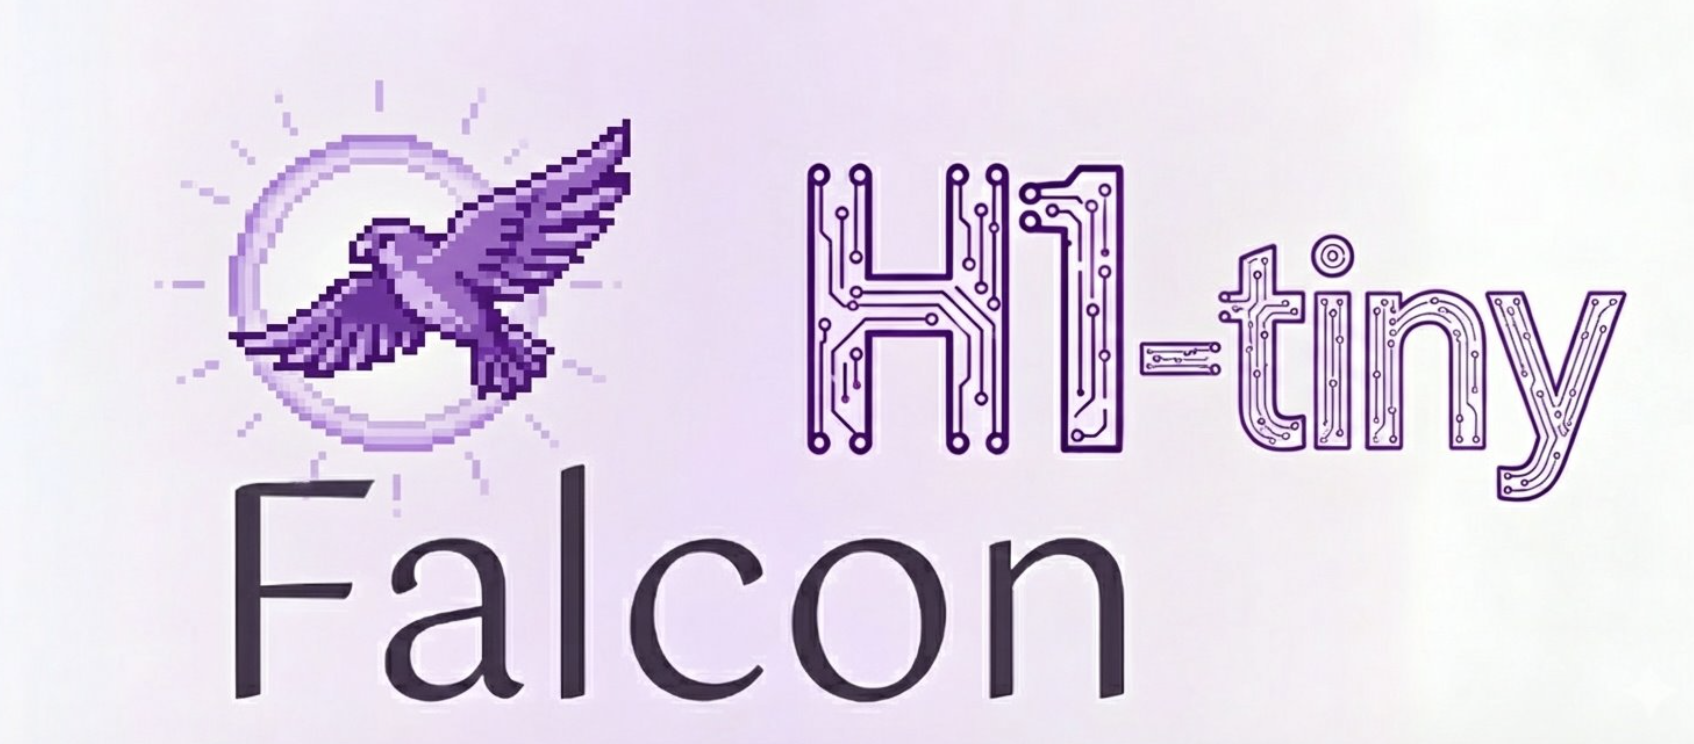

# 📘 Practical Guide to Finetuning **Falcon H1 Tiny** for Tool Calling Tasks

This notebook walks you through the process of **fine-tuning a Small Language Model (SLM)** to work with *tool calling* data — datasets that enable the model to understand and execute calls to external tools within a conversation, thereby enhancing automation capabilities and accuracy.

---

### Initial Model Checkpoint

For this tutorial, we will use **Falcon H1 tiny 90M instruct**, a compact variant of the Falcon H1 series developed by **TII**.

- **90 million parameters**, yet capable of effective conversational and instruction-following tasks.
- Runs smoothly on environments with limited resources such as laptops or edge devices.
- Designed to be **fast**, **lightweight**, and **easy to deploy**, making it ideal for learning and experimenting without large GPU infrastructure.

---

### Supervised Fine-Tuning with LoRA and TRL
In this notebook, we apply **Supervised Fine-Tuning (SFT)** techniques enhanced with **LoRA (Low-Rank Adaptation)**, using the **Hugging Face TRL** library to streamline training and evaluation. This combination allows efficient and cost-effective finetuning, even on limited hardware.

---

### Key Concepts
- **SFT**: Trains a model on example input–output pairs to align its behavior with a desired task.
- **Tool Calling**: The ability of a model to respond with a structured function call instead of free-form text.
- **LoRA**: Updates only a small set of low-rank parameters, reducing training cost and memory usage.
- **TRL**: The Hugging Face library that makes fine-tuning and reinforcement learning simple and efficient.

---

### What You Will Learn
By completing this notebook, you will:
1. Prepare tool calling datasets for finetuning.  
2. Configure and run the SFT process with LoRA/QLoRA using TRL.  
3. Validate the model's performance.  
4. Apply your custom LLM to real-world scenarios.

---

### Additional Resource: Pre‑Fine‑Tuned Tool‑Calling Model Available

If you'd like to skip the fine‑tuning process and try a ready‑to‑use model, the Technology Innovation Institute (TII) has already released a **Falcon H1 Tiny 90M** version fine‑tuned for tool‑calling tasks.
This model is optimized to handle structured function calls within conversations, making it ideal for automation workflows.

**References:**
- [Falcon H1 Tiny blog post](https://falconllm.tii.ae/blog/falcon-edge) — Overview of Falcon H1 Tiny series and use cases.
- [Falcon‑H1‑Tiny‑Tool‑Calling‑90M on Hugging Face](https://huggingface.co/tiiuae/Falcon-H1-Tiny-Tool-Calling-90M) — Pre‑fine‑tuned model weights.
- [Falcon H1 tiny 90M instruct model weights on Hugging Face](https://huggingface.co/tiiuae/Falcon-H1-Tiny-90M-Instruct)

### Install dependencies

We will install **TRL** with the *PEFT extra*, which includes key dependencies:
- **Transformers**
- **PEFT** *(parameter-efficient fine-tuning)*

We also install:
- **trackio** – for experiment logging
- **bitsandbytes** – to enable 8-bit optimizers

In [ ]:
!pip install -Uq "trl[peft]" trackio bitsandbytes

In [ ]:
!nvidia-smi

### Log in to Hugging Face

Log in to your Hugging Face account to push the fine-tuned model to the Hub and access gated models. You can find your access token on your [account settings page](https://huggingface.co/settings/tokens).

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

### Load Dataset

We load the [**bebechien/SimpleToolCalling**](https://huggingface.co/datasets/bebechien/SimpleToolCalling) dataset, which pairs user queries with the appropriate tool call needed to fulfill each request.

**Each record contains:**
- **`user_content`** – the user’s query.
- **`tool_name`** – the tool to be invoked.
- **`tool_arguments`** – the parameters to pass to the tool.

In [ ]:
from datasets import load_dataset

dataset_name = "bebechien/SimpleToolCalling"
dataset = load_dataset(dataset_name, split="train")

In [ ]:
print(dataset)

### Prepare Tool-Calling Data

We define two tools: `search_knowledge_base` for internal company documents and `search_google` for public information.  
We then write a custom **Jinja2 chat template** that extends the model's default template with two additions:

1. A **Tool Use** section is appended to the system preamble when `tools` is passed to `apply_chat_template`.  
2. Assistant turns with tool_calls render the call as structured <tool_call> blocks.
3. Each training sample uses the standard `tool_calls` message format with a `tools` key and `SFTTrainer` passes these to `apply_chat_template` automatically.

In [ ]:
import json

# These are the tool schemas that are used in the dataset
TOOLS = [
    {
        "type": "function",
        "function": {
            "name": "search_knowledge_base",
            "description": "Search internal company documents, policies and project data.",
            "parameters": {
                "type": "object",
                "properties": {"query": {"type": "string", "description": "query string"}},
                "required": ["query"],
            },
            "return": {"type": "string"},
        },
    },
    {
        "type": "function",
        "function": {
            "name": "search_google",
            "description": "Search public information.",
            "parameters": {
                "type": "object",
                "properties": {"query": {"type": "string", "description": "query string"}},
                "required": ["query"],
            },
            "return": {"type": "string"},
        },
    },
]

def create_conversation(sample):
    return {
        "prompt": [{"role": "user", "content": sample["user_content"]}],
        "completion": [
            {
                "role": "assistant",
                "tool_calls": [
                    {
                        "type": "function",
                        "function": {
                            "name": sample["tool_name"],
                            "arguments": json.loads(sample["tool_arguments"]),
                        },
                    }
                ],
            },
        ],
        "tools": TOOLS,
    }

In [ ]:
dataset = dataset.map(create_conversation, remove_columns=dataset.features)
# Split dataset into 80% training samples and 20% test samples
dataset = dataset.train_test_split(test_size=0.2, shuffle=True)

Let’s examine a sample from the training set to confirm the data format:

In [ ]:
print(dataset["train"][0])

We will verify that our dataset is properly divided into **training** and **test** sets:

In [ ]:
print(dataset)

✔ Split confirmed. The dataset is ready.  
Next, we will **load the model**.

### Load Model

In [ ]:
model_id, output_dir = "tiiuae/Falcon-H1-Tiny-90M-Instruct", "falcon-h1-tiny-90M-tool-calling-SFT"

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float16, # Change to bfloat16 if GPU has support
)

Let’s review the overall architecture of the model before proceeding:

In [ ]:
model

We will set up **LoRA** for fine-tuning.  
Instead of changing the model’s original weights, we train a lightweight **LoRA adapter**.

- **`target_modules`**: Specifies which layers receive the adapter.  
  Modify this if using a different model architecture.

In [ ]:
from peft import LoraConfig

peft_config = LoraConfig(
    r=32,
    lora_alpha=32,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj'],
)

> ⚠️ **Note:** The `out_proj` module (mamba output projection layer) is not compatible with **Mamba-based models** when using **LoRA** for fine-tuning.

### Train Model

We will set up the training process with **`SFTConfig`**.  
The configuration below is optimized for **low memory usage**.

📖 For a full list of available parameters, see the [TRL SFTConfig documentation](https://huggingface.co/docs/trl/main/en/sft_trainer#trl.SFTConfig).

In [ ]:
from trl import SFTConfig

training_args = SFTConfig(
    # Training schedule / optimization
    per_device_train_batch_size=1,       # Batch size per GPU
    gradient_accumulation_steps=4,       # Effective batch size = 1 * 4 = 4
    warmup_steps=5,
    learning_rate=2e-4,                  # Learning rate for the optimizer
    optim="paged_adamw_8bit",            # Optimizer

    # Evaluation
    eval_strategy="steps",               # Evaluate every N steps
    eval_steps=1,                        # Run evaluation every 5 steps

    # Logging / reporting
    logging_steps=1,                     # Log training metrics every N steps
    report_to="trackio",              # Experiment tracking tool (requires HF login)
    trackio_space_id=output_dir,      # HF Space where the experiment tracking will be saved
    output_dir=output_dir,               # Where to save model checkpoints and logs

    max_length=1024,                     # Maximum input sequence length
    activation_offloading=True,          # Offload activations to CPU to reduce GPU memory usage

    # Hub integration
    push_to_hub=True  # Automatically push the trained model to the Hugging Face Hub
)

> ⚠️ **Note:** The training parameters are tuned for a **Tesla T4 GPU**.  
> Make sure to adjust them to match your GPU’s specifications and capabilities.

In [ ]:
from trl import SFTTrainer

# Re-initialize Trainer with the updated evaluation config
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test'],
    peft_config=peft_config
)

Show memory stats before training:

In [ ]:
no_gpus = torch.cuda.device_count()
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)

print(f"Number of available GPUs: {no_gpus}")
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

**Ready to Train**

All configurations are set. Let’s start training!

In [ ]:
trainer_stats = trainer.train()

**Training & Validation Loss Curves**

Let's plot the **training loss** and **validation loss** over the training steps to observe the learning dynamics and detect potential issues such as overfitting.

In [ ]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

# Extract training loss (entries with 'loss' key but not 'eval_loss')
train_steps = [entry["step"] for entry in log_history if "loss" in entry and "eval_loss" not in entry]
train_loss = [entry["loss"] for entry in log_history if "loss" in entry and "eval_loss" not in entry]

# Extract validation loss
eval_steps = [entry["step"] for entry in log_history if "eval_loss" in entry]
eval_loss = [entry["eval_loss"] for entry in log_history if "eval_loss" in entry]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, label="Training Loss", marker="o", markersize=4)
plt.plot(eval_steps, eval_loss, label="Validation Loss", marker="s", markersize=4)
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Let’s review the GPU resources consumed during training.

In [ ]:
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)

print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training.")
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

### Save the Fine-Tuned Model
Save the trained LoRA adapter locally and push it to the Hugging Face Hub.

In [ ]:
trainer.save_model(output_dir)
trainer.push_to_hub()

### Load the Fine-Tuned Model and Run Inference
Load the trained LoRA adapter on top of the base model and merge it into the weights for efficient inference.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel

# Load from output_dir to get the tokenizer with the updated chat template
tokenizer = AutoTokenizer.from_pretrained(output_dir)

base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.float16,
    device_map="auto",
)

model = PeftModel.from_pretrained(base_model, output_dir)
model = model.merge_and_unload()
model.eval()

For inference using tool calls, we create a prediction function that leverages `apply_chat_template` with `tools=TOOLS` to build the prompt. The model outputs a JSON-formatted tool call wrapped in its native response delimiters; setting `skip_special_tokens=True` removes these delimiters, returning only the JSON string.

In [ ]:
def generate_prediction(prompt):
    text = tokenizer.apply_chat_template(
        prompt, tools=TOOLS, tokenize=False, add_generation_prompt=True
    )
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=512,
    )
    output_ids = generated_ids[0][len(model_inputs.input_ids[0]):]
    return tokenizer.decode(output_ids, skip_special_tokens=True)

Let's test the fine-tuned model on an example from the test set:

In [ ]:
sample_test_data = dataset["test"][0] # Get a sample from the test set
user_content = sample_test_data["prompt"]
print(f"User Query: {user_content}")

In [ ]:
predicted_output = generate_prediction(user_content)
print(f"Predicted Output: {predicted_output}")

In [ ]:
user_query = [{"role": "user", "content": "The price of a chicken"}]

predicted_output = generate_prediction(user_query)
print(f"Predicted Output: {predicted_output}")

The results look promising. Now, let’s run inference using the llama.cpp framework.

### Inference with llama.cpp

You now have a clear understanding of how to set up and fine-tune, resulting in your own customized model.

The next step is to use this model for inference with the `llama.cpp` framework.

**Step 1: Save Model and Tokenizer**

After merging the LoRA weights, save both the model and the tokenizer.
This step is **essential** to enable the subsequent conversion of the model into the `.gguf` format.

In [ ]:
finetuned_model_path = "/content/drive/MyDrive/falcon/falcon-h1-tiny-90M-tool-call-SFT"
model.save_pretrained(finetuned_model_path)
tokenizer.save_pretrained(finetuned_model_path)

print(f"Temp model saved")

**Step 2: Convert to `.gguf` Format**

The `.gguf` format will be used for serving within the `llama.cpp` framework, ensuring compatibility and efficient inference.

At this stage, it is advisable to download the model to a local environment and perform the conversion there. Executing the process directly on Colab requires installing additional dependencies for llama.cpp by running `pip install -r requirements.txt`. This process may result in extended version conflicts, which are common on Colab.

For those choosing to proceed on Colab, the necessary shell scripts for execution are provided below:

```bash
# Clone llama.cpp repository
git clone https://github.com/ggerganov/llama.cpp
cd llama.cpp

# Install required dependencies
pip install -r requirements.txt

# Convert Hugging Face model to GGUF format (quantized)
python convert_hf_to_gguf.py \
    /content/my_merged_model \
    --outfile /content/model-f16.gguf \
    --outtype f16

echo "Converted to GGUF"
```

After successfully converting the model locally, there are two options for uploading:

1. **Google Drive Folder** (while preserving the directory structure).  
2. **Hugging Face Hub**.

In this case, the **Google Drive folder** option will be used.

Now, run the inference.

In [ ]:
%cd /content
!git clone https://github.com/ggerganov/llama.cpp
%cd llama.cpp
!cmake -B build && cmake --build build --config Release -j$(nproc)

In [ ]:
# Build the full chat-template prompt (with tool schemas)
messages = [{"role": "user", "content": "candidate application processing workflow"}]
prompt = tokenizer.apply_chat_template(
    messages, tools=TOOLS, tokenize=False, add_generation_prompt=True
)

# Save prompt to a file
with open("/content/prompt.txt", "w") as f:
    f.write(prompt)

In [ ]:
# Execute llama-cli directly via shell
# Replace `/path/to/your/model.gguf` with the actual path to your GGUF model file.
!./build/bin/llama-cli \
    -m /content/falcon-tool-calling-gguf/model-f16.gguf \
    -f /content/prompt.txt \
    --temp 0.1

### Conclusion

In this tutorial, we have **successfully fine‑tuned** the `Falcon H1 Tiny 90M Instruct` model for **tool‑calling** tasks using **Supervised Fine‑Tuning (SFT)** with **LoRA** optimizations via the Hugging Face **TRL** library.

**Key achievements:**
- Prepared and structured tool‑calling datasets.
- Configured and executed the SFT training process efficiently on limited hardware.
- Validated model performance through training/validation metrics and inference tests.
- Demonstrated how a compact LLM can handle structured function calls within conversations, enabling better automation and accuracy.

For models fine-tuned at production scale with diverse tool schemas, we recommend evaluating on the [Berkeley Function Calling Leaderboard (BFCL)](https://github.com/ShishirPatil/gorilla), which tests generalization across hundreds of real-world APIs.